# Phase 2 Forecast-Aware Regime Layer Comparison

Compare the same operational regime-warning layer using QRC and ESN volatility forecasts.

Inputs required:

```bash
python scripts/export_final_qrc_predictions.py
python scripts/export_esn_predictions.py
```

In [1]:
from pathlib import Path
import os

if Path.cwd().name == 'notebooks':
    os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qpitome_qrc.data.loaders import load_phase2_volatility_data
from qpitome_qrc.data.splits import chronological_tabular_split

out_table_dir = Path('results/tables')
out_fig_dir = Path('results/figures')
out_table_dir.mkdir(parents=True, exist_ok=True)
out_fig_dir.mkdir(parents=True, exist_ok=True)

## 1. Rebuild test stress timeline

In [2]:
target = 'future_rv_20d'

def make_stress_features(frame):
    out = frame.copy().reset_index(drop=True)
    out['date'] = pd.to_datetime(out['date'])
    out['spy_selloff_stress'] = -out['spy_log_return']
    out['spy_oc_selloff_stress'] = -out['spy_log_oc_return']
    out['drawdown_stress'] = -out['spy_drawdown_20d'] if out['spy_drawdown_20d'].median() < 0 else out['spy_drawdown_20d']
    out['volume_stress'] = out['spy_log_volume_change'].abs()
    out['vix_level_stress'] = out['vix_close']
    out['vix_change_stress'] = out['vix_log_change'].clip(lower=0.0)
    out['vix_range_stress'] = out['vix_log_hl_range']
    out['realized_vol_stress'] = out['rv_20d']
    return out

df = load_phase2_volatility_data()
splits = chronological_tabular_split(df)
splits = {k: make_stress_features(v) for k, v in splits.items()}
train, val, test = splits['train'], splits['val'], splits['test']

thresholds = {
    'high_vol_q80': float(train[target].quantile(0.80)),
    'extreme_vol_q90': float(train[target].quantile(0.90)),
    'crisis_candidate_q95': float(train[target].quantile(0.95)),
}

for split in [train, val, test]:
    split['future_high_vol_event_q80'] = split[target] > thresholds['high_vol_q80']
    split['future_extreme_vol_event_q90'] = split[target] > thresholds['extreme_vol_q90']
    split['future_crisis_candidate_q95'] = split[target] > thresholds['crisis_candidate_q95']

events = [
    'future_high_vol_event_q80',
    'future_extreme_vol_event_q90',
    'future_crisis_candidate_q95',
]

def q(col, quantile, split=train):
    return float(split[col].quantile(quantile))

timeline = test.copy().reset_index(drop=True)
timeline['direction_tag'] = 'neutral'
timeline.loc[timeline['spy_log_return'] >= q('spy_log_return', 0.70), 'direction_tag'] = 'rally'
timeline.loc[timeline['spy_log_return'] <= q('spy_log_return', 0.30), 'direction_tag'] = 'selloff'

flag_specs = {
    'flag_realized_vol': ('rv_20d', 0.80),
    'flag_vix_level': ('vix_close', 0.80),
    'flag_vix_range': ('vix_log_hl_range', 0.80),
    'flag_drawdown': ('drawdown_stress', 0.80),
    'flag_selloff': ('spy_selloff_stress', 0.80),
    'flag_volume': ('volume_stress', 0.80),
    'flag_vol_acceleration': ('rv_slope_5_20', 0.80),
}
for flag, (col, quantile) in flag_specs.items():
    timeline[flag] = timeline[col] > q(col, quantile)

timeline[['date', target] + events].head()

,date,future_rv_20d,future_high_vol_event_q80,future_extreme_vol_event_q90,future_crisis_candidate_q95
0,2020-01-02,0.117560,False,False,False
1,2020-01-03,0.117399,False,False,False
2,2020-01-06,0.128385,False,False,False
3,2020-01-07,0.134328,False,False,False
4,2020-01-08,0.133529,False,False,False


## 2. Load QRC and ESN forecast tables

In [3]:
qrc_path = out_table_dir / 'phase2_qrc_final_encoding_readout_predictions.csv'
esn_path = out_table_dir / 'phase2_esn_predictions.csv'

for path, cmd in [
    (qrc_path, 'python scripts/export_final_qrc_predictions.py'),
    (esn_path, 'python scripts/export_esn_predictions.py'),
]:
    if not path.exists():
        raise FileNotFoundError(f'Missing {path}. Run: {cmd}')

qrc = pd.read_csv(qrc_path)
esn = pd.read_csv(esn_path)
qrc['date'] = pd.to_datetime(qrc['date'])
esn['date'] = pd.to_datetime(esn['date'])

qrc = qrc[['date', 'actual_future_rv_20d', 'qrc_pred_future_rv_20d']]
esn = esn[['date', 'actual_future_rv_20d', 'esn_pred_future_rv_20d']]

display(qrc.head())
display(esn.head())

,date,actual_future_rv_20d,qrc_pred_future_rv_20d
0,2020-02-28,0.923201,0.168038
1,2020-03-02,0.917891,0.179526
2,2020-03-03,0.913637,0.200856
3,2020-03-04,0.916564,0.158109
4,2020-03-05,0.912276,0.170180


,date,actual_future_rv_20d,esn_pred_future_rv_20d
0,2020-02-28,0.923201,0.302564
1,2020-03-02,0.917891,0.278501
2,2020-03-03,0.913637,0.336297
3,2020-03-04,0.916564,0.291668
4,2020-03-05,0.912276,0.337469


## 3. Shared forecast-aware regime function

In [4]:
def build_forecast_regime_layer(forecast_table, pred_col, model_name):
    layer = timeline.merge(forecast_table, on='date', how='inner')
    layer['model'] = model_name
    layer['pred_future_rv_20d'] = layer[pred_col]

    layer['forecast_high_vol'] = layer['pred_future_rv_20d'] > thresholds['high_vol_q80']
    layer['forecast_extreme_vol'] = layer['pred_future_rv_20d'] > thresholds['extreme_vol_q90']
    layer['forecast_crisis_vol'] = layer['pred_future_rv_20d'] > thresholds['crisis_candidate_q95']

    confirm_cols = ['flag_vix_level', 'flag_vix_range', 'flag_drawdown', 'flag_selloff', 'flag_volume']
    layer['confirm_score'] = layer[confirm_cols].sum(axis=1)

    layer['forecast_regime'] = 'normal'
    layer.loc[layer['forecast_high_vol'] | (layer['confirm_score'] >= 2), 'forecast_regime'] = 'watch'
    layer.loc[
        (layer['forecast_high_vol'] & (layer['confirm_score'] >= 1)) | layer['forecast_extreme_vol'],
        'forecast_regime',
    ] = 'warning'
    layer.loc[
        (
            layer['forecast_extreme_vol']
            & (layer['confirm_score'] >= 2)
            & (layer['flag_drawdown'] | layer['flag_selloff'] | layer['flag_vix_level'])
        )
        | (
            layer['forecast_high_vol']
            & (layer['confirm_score'] >= 4)
            & (layer['flag_drawdown'] | layer['flag_vix_level'])
        ),
        'forecast_regime',
    ] = 'crisis_like'

    layer['forecast_regime_descriptor'] = layer['forecast_regime'] + '_' + layer['direction_tag']
    return layer

qrc_layer = build_forecast_regime_layer(qrc, 'qrc_pred_future_rv_20d', 'QRC')
esn_layer = build_forecast_regime_layer(esn, 'esn_pred_future_rv_20d', 'ESN')

display(qrc_layer.groupby(['model', 'forecast_regime', 'direction_tag']).size().reset_index(name='n'))
display(esn_layer.groupby(['model', 'forecast_regime', 'direction_tag']).size().reset_index(name='n'))

,model,forecast_regime,direction_tag,n
0,QRC,crisis_like,neutral,7
1,QRC,crisis_like,rally,8
2,QRC,crisis_like,selloff,43
3,QRC,normal,neutral,284
4,QRC,normal,rally,197
5,QRC,normal,selloff,87
6,QRC,warning,neutral,36
7,QRC,warning,rally,90
8,QRC,warning,selloff,62
9,QRC,watch,neutral,23


,model,forecast_regime,direction_tag,n
0,ESN,crisis_like,neutral,14
1,ESN,crisis_like,rally,35
2,ESN,crisis_like,selloff,78
3,ESN,normal,neutral,300
4,ESN,normal,rally,223
5,ESN,normal,selloff,95
6,ESN,warning,neutral,23
7,ESN,warning,rally,49
8,ESN,warning,selloff,37
9,ESN,watch,neutral,13


## 4. Evaluate QRC vs ESN regime warnings

In [5]:
def flag_metrics(signal, event):
    signal = pd.Series(signal).astype(bool).to_numpy()
    event = pd.Series(event).astype(bool).to_numpy()
    tp = int(np.sum(signal & event))
    fp = int(np.sum(signal & ~event))
    fn = int(np.sum(~signal & event))
    tn = int(np.sum(~signal & ~event))
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return {'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn, 'precision': precision, 'recall': recall, 'f1': f1, 'signal_rate': float(signal.mean())}

def evaluate_layer(layer):
    signal_defs = {
        'watch_or_higher': layer['forecast_regime'].isin(['watch', 'warning', 'crisis_like']),
        'warning_or_higher': layer['forecast_regime'].isin(['warning', 'crisis_like']),
        'crisis_like': layer['forecast_regime'].eq('crisis_like'),
    }
    rows = []
    for signal_name, signal in signal_defs.items():
        for event in events:
            row = {'model': layer['model'].iloc[0], 'signal': signal_name, 'event': event}
            row.update(flag_metrics(signal, layer[event]))
            rows.append(row)
    return pd.DataFrame(rows)

regime_compare = pd.concat([evaluate_layer(qrc_layer), evaluate_layer(esn_layer)], ignore_index=True)
regime_compare = regime_compare.sort_values(['event', 'signal', 'model'])
regime_compare.to_csv(out_table_dir / 'phase2_qrc_vs_esn_forecast_regime_eval.csv', index=False)
regime_compare

,model,signal,event,tp,fp,fn,tn,precision,recall,f1,signal_rate
17,ESN,crisis_like,future_crisis_candidate_q95,29,98,5,887,0.228346,0.852941,0.360248,0.124632
8,QRC,crisis_like,future_crisis_candidate_q95,9,49,25,936,0.155172,0.264706,0.195652,0.056919
14,ESN,warning_or_higher,future_crisis_candidate_q95,31,205,3,780,0.131356,0.911765,0.229630,0.231600
5,QRC,warning_or_higher,future_crisis_candidate_q95,18,228,16,757,0.073171,0.529412,0.128571,0.241413
11,ESN,watch_or_higher,future_crisis_candidate_q95,32,369,2,616,0.079800,0.941176,0.147126,0.393523
2,QRC,watch_or_higher,future_crisis_candidate_q95,32,419,2,566,0.070953,0.941176,0.131959,0.442591
16,ESN,crisis_like,future_extreme_vol_event_q90,58,69,53,839,0.456693,0.522523,0.487395,0.124632
7,QRC,crisis_like,future_extreme_vol_event_q90,18,40,93,868,0.310345,0.162162,0.213018,0.056919
13,ESN,warning_or_higher,future_extreme_vol_event_q90,89,147,22,761,0.377119,0.801802,0.512968,0.231600
4,QRC,warning_or_higher,future_extreme_vol_event_q90,71,175,40,733,0.288618,0.639640,0.397759,0.241413


## 5. Compare F1 curves

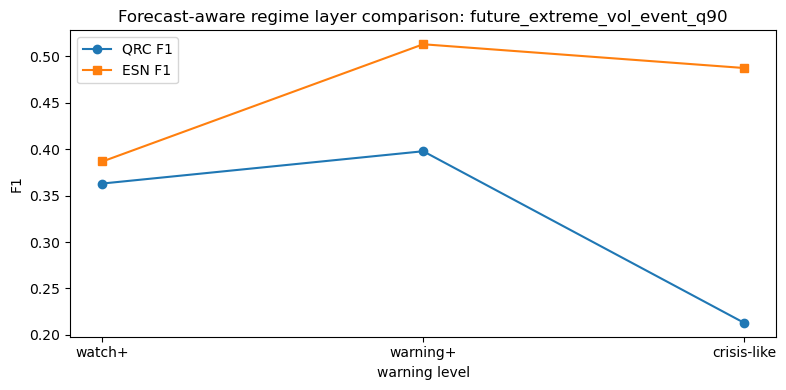

In [6]:
event_to_plot = 'future_extreme_vol_event_q90'
signal_order = ['watch_or_higher', 'warning_or_higher', 'crisis_like']
x = np.arange(len(signal_order))

fig, ax = plt.subplots(figsize=(8, 4))
for model_name, marker in [('QRC', 'o'), ('ESN', 's')]:
    part = (
        regime_compare[(regime_compare['event'] == event_to_plot) & (regime_compare['model'] == model_name)]
        .set_index('signal')
        .loc[signal_order]
        .reset_index()
    )
    ax.plot(x, part['f1'], marker=marker, label=f'{model_name} F1')

ax.set_title(f'Forecast-aware regime layer comparison: {event_to_plot}')
ax.set_xlabel('warning level')
ax.set_ylabel('F1')
ax.set_xticks(x)
ax.set_xticklabels(['watch+', 'warning+', 'crisis-like'])
ax.legend()
fig.tight_layout()
fig.savefig(out_fig_dir / 'phase2_qrc_vs_esn_forecast_regime_f1_q90.png', dpi=180)
plt.show()

## 6. Forecast timeline comparison

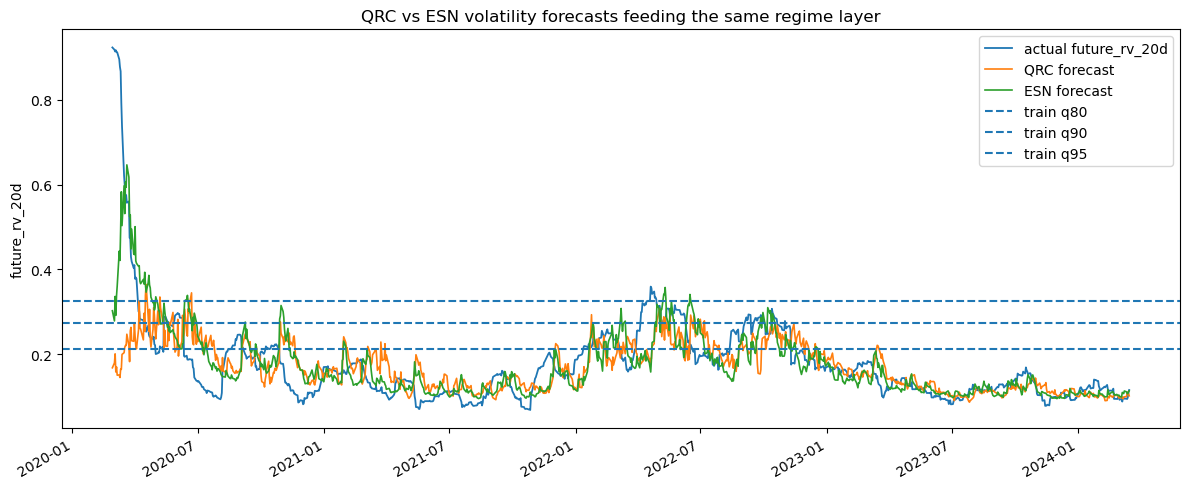

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(qrc_layer['date'], qrc_layer['actual_future_rv_20d'], label='actual future_rv_20d', linewidth=1.3)
ax.plot(qrc_layer['date'], qrc_layer['pred_future_rv_20d'], label='QRC forecast', linewidth=1.2)
ax.plot(esn_layer['date'], esn_layer['pred_future_rv_20d'], label='ESN forecast', linewidth=1.2)
ax.axhline(thresholds['high_vol_q80'], linestyle='--', label='train q80')
ax.axhline(thresholds['extreme_vol_q90'], linestyle='--', label='train q90')
ax.axhline(thresholds['crisis_candidate_q95'], linestyle='--', label='train q95')
ax.set_title('QRC vs ESN volatility forecasts feeding the same regime layer')
ax.set_ylabel('future_rv_20d')
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(out_fig_dir / 'phase2_qrc_vs_esn_forecast_timeline.png', dpi=180)
plt.show()

## 7. Interpretation checkpoint

The same regime-warning layer can be driven by either QRC or ESN forecasts. ESN is the stronger classical reservoir reference and should usually improve forecast-aware warning performance. This comparison separates application-layer value from quantum-reservoir-specific forecasting performance.